In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df=pd.read_csv("train2.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [4]:
df.sample()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
139956,139956,49,60794.0,50.6,2,11,12,4.0,Female,Urban,Sedan,No,No,Low,No


In [5]:
df.columns

Index(['id', 'Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

In [6]:
df.value_counts('Home_Charging_Possible')

Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64

In [7]:
df[df['Gender']=='Other'].value_counts('Will_Buy_EV')

Will_Buy_EV
No     4366
Yes     918
Name: count, dtype: int64

In [24]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [9]:
result = df[df['Will_Buy_EV'] == 'Yes']['AgeGroup'].value_counts().sort_index()

print(result)

AgeGroup
18-25     1917
26-35    26403
36-45    25060
46-55    29702
56-65    24027
65+       9670
Name: count, dtype: int64


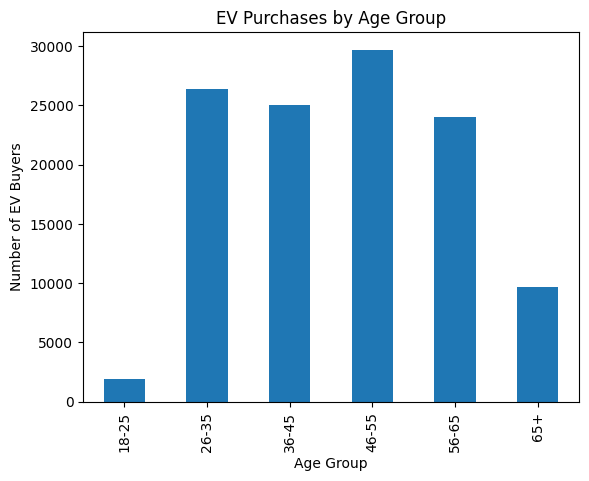

In [10]:
result.plot(kind='bar')
plt.xlabel("Age Group")
plt.ylabel("Number of EV Buyers")
plt.title("EV Purchases by Age Group")
plt.show()

In [25]:
df.drop('AgeGroup',axis=1,inplace=True)

In [26]:
df.sample()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
511374,511374,69,30000.0,67.3,2,1,5,2.0,Male,Suburban,Hatchback,Yes,Yes,Low,No


In [18]:
from sklearn.preprocessing import OneHotEncoder

In [27]:
dum=df.copy()
categorical_cols = ['Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level']
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

encoded = encoder.fit_transform(dum[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=dum.index
)

# Original categorical columns remove
dum = dum.drop(columns=categorical_cols)

# Encoded columns + all remaining columns
dum = pd.concat([dum, encoded_df], axis=1)

In [29]:
df=dum.copy()

In [30]:
df.sample(3)

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV,Gender_Male,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_Yes,Subsidy_Available_Yes,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
433245,433245,35,30000.0,19.8,1,8,7,5.0,No,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
456505,456505,63,84463.0,59.5,2,2,11,2.0,No,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
569300,569300,37,81562.0,49.8,3,9,19,1.0,No,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0


In [31]:
df.drop('id',axis=1,inplace=True)

In [33]:
df.sample()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV,Gender_Male,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_Yes,Subsidy_Available_Yes,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
95843,43,103890.0,5.0,1,5,10,3.0,No,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0


In [35]:
df['Will_Buy_EV']=df['Will_Buy_EV'].map({'Yes':1,'No':0})

In [36]:
X=df.drop('Will_Buy_EV',axis=1)
y=df[['Will_Buy_EV']]

In [38]:
from sklearn.model_selection import train_test_split

In [45]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)

In [40]:
from sklearn.preprocessing import StandardScaler

In [46]:
X_scaler=StandardScaler()
X_train=X_scaler.fit_transform(X_train)
X_test=X_scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LogisticRegression

In [53]:
from sklearn.metrics import classification_report

In [58]:
model = LogisticRegression(C=10)
model.fit(X_train, y_train)
pred=model.predict(X_test)
print(classification_report(y_test, pred))

C:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.72      0.66      0.69     23193

    accuracy                           0.90    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.90      0.89    133733



In [72]:
from xgboost import XGBClassifier
model = XGBClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94    110540
           1       0.72      0.67      0.70     23193

    accuracy                           0.90    133733
   macro avg       0.83      0.81      0.82    133733
weighted avg       0.90      0.90      0.90    133733



In [76]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [77]:
model=XGBClassifier()
model.fit(X,y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [78]:
df=pd.read_csv('test.csv')

In [79]:
df

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286566,955231,63,75830.0,23.9,1,3,3,1.0,Male,Suburban,SUV,Yes,No,Low
286567,955232,27,79563.0,55.2,2,7,5,3.0,Male,Suburban,Sedan,Yes,Yes,Low
286568,955233,30,48183.0,42.6,3,7,7,4.0,Female,Suburban,Sedan,Yes,No,Low
286569,955234,32,107845.0,5.0,2,14,7,1.0,Female,Urban,SUV,No,No,Low


In [80]:
dum=df.copy()
categorical_cols = ['Gender',
       'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level']


encoded = encoder.transform(dum[categorical_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=dum.index
)

# Original categorical columns remove
dum = dum.drop(columns=categorical_cols)

# Encoded columns + all remaining columns
dum = pd.concat([dum, encoded_df], axis=1)

In [81]:
dum

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Male,Gender_Other,City_Type_Suburban,City_Type_Urban,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_Yes,Subsidy_Available_Yes,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
0,668665,61,67725.0,16.9,2,7,4,4.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,668666,42,152835.0,41.9,2,9,9,4.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,668667,68,86877.0,53.3,1,10,11,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,668668,39,46794.0,34.1,2,4,8,4.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,668669,55,112172.0,57.2,1,6,4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286566,955231,63,75830.0,23.9,1,3,3,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
286567,955232,27,79563.0,55.2,2,7,5,3.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
286568,955233,30,48183.0,42.6,3,7,7,4.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
286569,955234,32,107845.0,5.0,2,14,7,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [84]:
dum.drop('id',axis=1,inplace=True)

In [86]:
dum=scaler.transform(dum)

In [109]:
prob=model.predict_proba(dum)[:, 1]

In [112]:
prob

array([8.3378600e-03, 2.1372668e-02, 4.2249318e-03, ..., 2.3505220e-03,
       2.3670431e-04, 9.0447211e-05], shape=(286571,), dtype=float32)

In [113]:
sub=pd.DataFrame(df['id'])

In [115]:
sub['Will_Buy_EV']=prob

In [116]:
sub.describe()

,id,Will_Buy_EV
count,286571.000000,286571.000000
mean,811950.000000,0.174697
std,82726.066333,0.270676
min,668665.000000,0.000003
25%,740307.500000,0.002299
50%,811950.000000,0.017587
75%,883592.500000,0.265496
max,955235.000000,0.981818


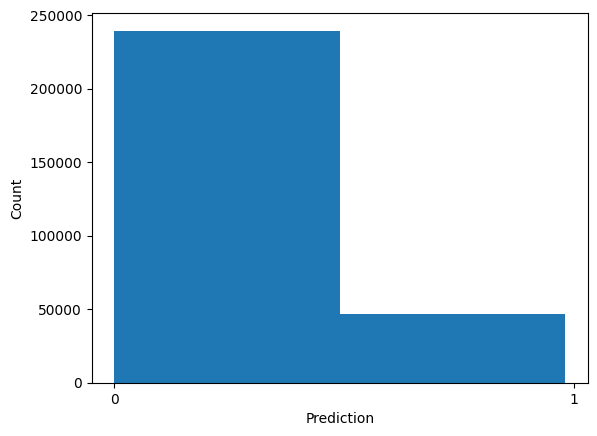

In [101]:
import matplotlib.pyplot as plt
plt.hist(pred, bins=2)
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.xticks([0, 1])
plt.show()

In [103]:
sub['id']=df['id']

In [104]:
sub

,Will_Buy_EV,id
0,0.008338,668665
1,0.021373,668666
2,0.004225,668667
3,0.002287,668668
4,0.015384,668669
...,...,...
286566,0.000085,955231
286567,0.209862,955232
286568,0.002351,955233
286569,0.000237,955234


In [117]:
sub

,id,Will_Buy_EV
0,668665,0.008338
1,668666,0.021373
2,668667,0.004225
3,668668,0.002287
4,668669,0.015384
...,...,...
286566,955231,0.000085
286567,955232,0.209862
286568,955233,0.002351
286569,955234,0.000237


In [118]:
sub.to_csv('submission.csv', index=False)